# Partitioning Analysis

## Setup

In [1]:
from pathlib import Path
import sys, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import QuantileTransformer, StandardScaler

HERE = Path.cwd()
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

from partitioning import _build_partitioner, PARTITIONER_REGISTRY, PREPROCESSOR_REGISTRY

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(42)

METADATA_CSV = HERE / 'files' / 'train_N28.csv'
N_PARTITIONS = 20
SEED = 42

# Utilization ranking of PARTITIONING_ANALYSIS.md §4.1: (0.70, 0.75) low /
# (0.80) medium / (0.85, 0.90) high, cutting the design x utilization grid
# from 30 cells to 18.  It shapes the split tree only -- with
# keep_in_output=False (the default) every partition handed back still
# carries the raw 0.7-0.9 value, so the composition / JS / coverage panels
# below stay on the same 5-level scale for every strategy and remain
# comparable.  Flip it to True to see the clients described by rank instead.
RANK_UTILIZATION = {
    'type': 'rank_utilization',
    'column': 'utilization',
    'keep_in_output': False,
    'levels': {'low': [0.70, 0.75], 'medium': [0.80], 'high': [0.85, 0.90]},
}

STRATEGIES = [
    {'name': 'iid', 'cfg': {'type': 'iid', 'n_partitions': N_PARTITIONS, 'mode': 'features'}},
    {'name': 'kmeans', 'cfg': {'type': 'kmeans', 'n_partitions': N_PARTITIONS, 'cluster_share': 0.8, 'dirichlet_alpha': 0.5, 'random_state': SEED}},
    {'name': 'dirichlet', 'cfg': {'type': 'dirichlet', 'n_partitions': N_PARTITIONS, 'features': ['design_name', 'utilization', 'clock'], 'alpha': 0.5, 'random_state': SEED}},
    {'name': 'feature_hierarchical', 'cfg': {'type': 'feature_hierarchical', 'n_partitions': N_PARTITIONS, 'features': ['design_name', 'utilization', 'clock'], 'preprocessing': [RANK_UTILIZATION], 'cluster_share': 0.8, 'dirichlet_alpha': 0.5, 'random_state': SEED}},
]

print('registry:', list(PARTITIONER_REGISTRY))
print('preproc :', list(PREPROCESSOR_REGISTRY))
print('csv     :', METADATA_CSV)
print('K       :', N_PARTITIONS)

registry: ['iid', 'kmeans', 'dirichlet', 'feature_hierarchical']
preproc : ['ordinal_rank', 'rank_utilization']
csv     : /home/spedicato/FedCircuitNet/files/train_N28.csv
K       : 20


## Load Metadata

In [2]:
df = pd.read_csv(METADATA_CSV)
print('shape:', df.shape)
df.head()

shape: (7077, 9)


,filename,sample_id,design_name,macro_count,clock,utilization,macro_placement,power_mesh,filler_insertion
0,2187-RISCY-b-1-c2-u0.8-m1-p8-f1,2187,RISCY-b,1,2,0.80,1,8,1
1,5107-RISCY-FPU-a-2-c20-u0.7-m1-p2-f1,5107,RISCY-FPU-a,2,20,0.70,1,2,1
2,1523-RISCY-a-3-c2-u0.75-m2-p5-f1,1523,RISCY-a,3,2,0.75,2,5,1
3,6155-RISCY-FPU-b-1-c5-u0.85-m3-p5-f1,6155,RISCY-FPU-b,1,5,0.85,3,5,1
4,3316-RISCY-b-2-c20-u0.8-m3-p5-f1,3316,RISCY-b,2,20,0.80,3,5,1


In [3]:
META_COLS = [c for c in df.columns if c not in ('filename', 'sample_id')]
summary = pd.DataFrame({
    'dtype': [df[c].dtype for c in META_COLS],
    'n_unique': [df[c].nunique() for c in META_COLS],
    'unique_values': [sorted(df[c].astype(str).unique().tolist()) for c in META_COLS],
})
summary.index.name = 'feature'
summary

,dtype,n_unique,unique_values
feature,,,
0,object,4,"[RISCY-FPU-a, RISCY-FPU-b, RISCY-a, RISCY-b]"
1,int64,3,"[1, 2, 3]"
2,int64,3,"[2, 20, 5]"
3,float64,5,"[0.7, 0.75, 0.8, 0.85, 0.9]"
4,int64,4,"[1, 2, 3, 4]"
5,int64,8,"[1, 2, 3, 4, 5, 6, 7, 8]"
6,int64,2,"[0, 1]"


## Global Metadata Frequency

In [4]:
n = len(META_COLS)
cols = 3
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(5.5 * cols, 3.6 * rows))
axes = np.array(axes).ravel()
for ax, col in zip(axes, META_COLS):
    vc = df[col].astype(str).value_counts().sort_index()
    sns.barplot(x=vc.index, y=vc.values, ax=ax, color='#4C72B0')
    ax.set_title(f'{col} (global frequency)')
    ax.set_xlabel(col)
    ax.set_ylabel('count')
    ax.tick_params(axis='x', rotation=30)
for ax in axes[n:]:
    ax.set_visible(False)
fig.suptitle(f'Global metadata frequency  (N={len(df)})', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

<Figure size 1650x1080 with 9 Axes>

## Run Partitioners

In [5]:
def build_assignment(parts):
    assignment = np.full(len(df), -1, dtype=int)
    lookup = {name: i for i, name in enumerate(df['filename'].to_numpy())}
    for i, p in enumerate(parts):
        for name in p['filename']:
            assignment[lookup[name]] = i
    return assignment


results = {}
for entry in STRATEGIES:
    part = _build_partitioner(dict(entry['cfg']))
    parts = part.partition(df)
    results[entry['name']] = {
        'partitioner': part,
        'parts': parts,
        'assignment': build_assignment(parts),
        'sizes': [len(p) for p in parts],
    }
    print(f"{entry['name']:14s}  cls={part.__class__.__name__:24s}  sizes={results[entry['name']]['sizes']} Total={sum(results[entry['name']]['sizes'])}  n_parts={len(parts)}")

STRAT_NAMES = list(results)

iid             cls=IIDPartitioner            sizes=[354, 354, 354, 354, 354, 354, 354, 354, 354, 354, 354, 354, 354, 354, 354, 354, 354, 353, 353, 353] Total=7077  n_parts=20
kmeans          cls=KMeansClustering          sizes=[391, 268, 448, 239, 309, 297, 368, 216, 355, 510, 352, 498, 261, 422, 301, 388, 301, 339, 533, 281] Total=7077  n_parts=20
dirichlet       cls=DirichletPartitioner      sizes=[263, 377, 345, 284, 465, 326, 316, 292, 341, 319, 321, 404, 414, 256, 416, 405, 408, 386, 359, 380] Total=7077  n_parts=20
feature_hierarchical  cls=FeatureHierarchicalPartitioner  sizes=[482, 455, 483, 480, 462, 449, 464, 453, 365, 303, 315, 303, 306, 286, 274, 320, 267, 164, 215, 231] Total=7077  n_parts=20


## Partition Size Comparison

In [6]:
sizes_df = pd.DataFrame({name: results[name]['sizes'] for name in STRAT_NAMES},
                        index=[f'P{i}' for i in range(N_PARTITIONS)])
sizes_df.loc['TOTAL'] = sizes_df.sum()
sizes_df.loc['MIN'] = sizes_df.iloc[:N_PARTITIONS].min()
sizes_df.loc['MAX'] = sizes_df.iloc[:N_PARTITIONS].max()
sizes_df.loc['STD'] = sizes_df.iloc[:N_PARTITIONS].std().round(1)
sizes_df

,iid,kmeans,dirichlet,feature_hierarchical
P0,354.0,391.0,263.0,482.0
P1,354.0,268.0,377.0,455.0
P2,354.0,448.0,345.0,483.0
P3,354.0,239.0,284.0,480.0
P4,354.0,309.0,465.0,462.0
P5,354.0,297.0,326.0,449.0
P6,354.0,368.0,316.0,464.0
P7,354.0,216.0,292.0,453.0
P8,354.0,355.0,341.0,365.0
P9,354.0,510.0,319.0,303.0


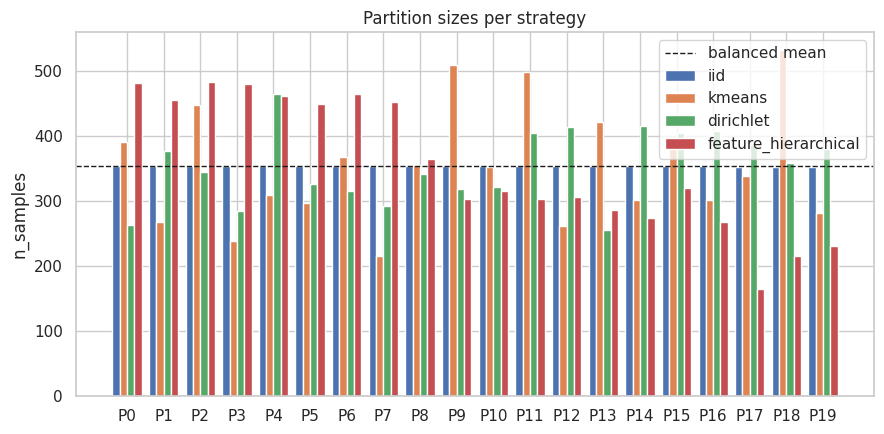

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(N_PARTITIONS)
width = 0.8 / len(STRAT_NAMES)
palette = sns.color_palette('deep', len(STRAT_NAMES))
for i, name in enumerate(STRAT_NAMES):
    ax.bar(x + (i - (len(STRAT_NAMES) - 1) / 2) * width,
           results[name]['sizes'], width, label=name, color=palette[i])
ax.set_xticks(x)
ax.set_xticklabels([f'P{i}' for i in range(N_PARTITIONS)])
ax.set_ylabel('n_samples')
ax.set_title('Partition sizes per strategy')
ax.axhline(len(df) / N_PARTITIONS, ls='--', color='k', lw=1, label='balanced mean')
ax.legend()
fig.tight_layout()
plt.show()

## Per-Partition Composition

One panel per metadata factor; one bar per partition, stacked to 100 % by
level (charts ported from `plot_cluster_histograms` in
`code_examples/202608061500_partitioning_analysis/kmeans_test_n28.ipynb`).

Every bar is the same height, so a panel is read by **composition**, not by
height:

- a bar filled with a single colour is a partition that is **pure** on that
  factor -- the partitioner split on it;
- a bar whose segments repeat the same proportions as its neighbours is a
  factor the partitioner **ignored**;
- comparing panels across strategies shows *which knob* each scheme actually
  turned into client heterogeneity.

In [8]:
# Per-partition composition charts, ported from `plot_cluster_histograms` in
# code_examples/202608061500_partitioning_analysis/kmeans_test_n28.ipynb.
# Only the vocabulary differs: that notebook labels the units "cluster", here
# they are FL clients, so the axis reads "partition" and the ticks are P0..PK-1.

SEQ_CMAP = 'Blues'          # single-hue ramp for the many-levels fallback
INK = '#2c3e50'

# Categorical slots for level identity, used in fixed order and never cycled.
# Validated for adjacent-pair CVD separation against a '#f5f5f5' axes surface.
# In these panels the hue identifies the factor *level* while its position up
# the stack carries the level order, so an ordered factor needs no extra ramp.
SERIES_COLORS = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100',
                 '#e87ba4', '#008300', '#4a3aa7', '#e34948']

# Ink for a label drawn on top of each slot's fill, picked per slot as the
# more legible of white / INK.
SERIES_INK = ['white', INK, INK, INK, INK, 'white', 'white', 'white']

# The palette assumes the reference notebook's grey panel; apply it locally so
# the rest of this notebook keeps its seaborn theme.
COMPOSITION_RC = {
    'axes.grid': True, 'grid.color': 'white', 'grid.linewidth': 0.8,
    'axes.facecolor': '#f5f5f5', 'figure.facecolor': 'white',
}


def factor_levels(series):
    """Level labels of a factor, numerically ordered when possible."""
    vals = series.astype(str).unique()
    try:
        return sorted(vals, key=float)
    except ValueError:
        return sorted(vals)


def partition_profile(frame, labels, factor):
    """(count, percent-within-partition) for one factor; partitions are rows.

    Columns keep the factor's natural level order (numeric where the levels
    are numbers) rather than the lexicographic order `crosstab` would give,
    otherwise the bar positions stop carrying the ordering.
    """
    counts = pd.crosstab(pd.Series(labels, index=frame.index, name='partition'),
                         frame[factor].astype(str))
    counts = counts.reindex(columns=factor_levels(frame[factor]), fill_value=0)
    pct = (counts.div(counts.sum(axis=1), axis=0) * 100).round(2)
    return counts, pct


def plot_partition_heatmaps(frame, labels, factors, title, ncols=2):
    """Fallback for many levels: shade = % within partition, cell = count."""
    parts = sorted(pd.unique(labels))
    nrows = int(np.ceil(len(factors) / ncols))
    panel_h = 0.30 * len(parts) + 1.2
    with plt.rc_context(COMPOSITION_RC):
        fig, axes = plt.subplots(nrows, ncols, figsize=(7.6 * ncols, panel_h * nrows))
        axes = np.atleast_1d(axes).ravel()

        for ax, f in zip(axes, factors):
            counts, pct = partition_profile(frame, labels, f)
            ax.imshow(pct.values, cmap=SEQ_CMAP, vmin=0, vmax=100, aspect='auto')
            ax.set_xticks(range(counts.shape[1]))
            ax.set_xticklabels([str(c) for c in counts.columns], fontsize=8)
            ax.set_yticks(range(len(parts)))
            ax.set_yticklabels([f'P{c}' for c in parts], fontsize=8)
            for i in range(counts.shape[0]):
                for j in range(counts.shape[1]):
                    ax.text(j, i, f'{counts.values[i, j]:,}', ha='center',
                            va='center', fontsize=7,
                            color='white' if pct.values[i, j] > 55 else INK)
            ax.set_title(f'{f}   (cell = count, shade = % within partition)', fontsize=9)
            ax.grid(False)
            ax.tick_params(length=0)

        for ax in axes[len(factors):]:
            ax.axis('off')

        fig.suptitle(title, y=1.01)
        plt.tight_layout(); plt.show()


def plot_cluster_histograms(frame, labels, factors, title, ncols=2, label_min=8.0):
    """One panel per factor: one bar per partition, stacked to 100 % by level.

    Every bar is the same height, so the panel is read by *composition* rather
    than by height: a bar filled with a single colour is a partition that is
    pure on that factor, and a bar whose segments repeat the same proportions
    as its neighbours is a factor the partitioner ignored.

    Segment values are printed inside the fill when a panel has at most four
    levels and the segment is at least `label_min` percent tall -- below that
    the label would not fit inside its own segment.
    """
    parts = sorted(pd.unique(labels))
    too_many = [f for f in factors if frame[f].nunique() > len(SERIES_COLORS)]
    if too_many:
        print(f'{title}: {too_many} have more levels than the '
              f'{len(SERIES_COLORS)} categorical slots -- drawn as heatmaps '
              'instead of stacked bars.')
        return plot_partition_heatmaps(frame, labels, factors, title, ncols)

    nrows = int(np.ceil(len(factors) / ncols))
    with plt.rc_context(COMPOSITION_RC):
        fig, axes = plt.subplots(nrows, ncols, figsize=(7.6 * ncols, 3.2 * nrows))
        axes = np.atleast_1d(axes).ravel()
        xs = np.arange(len(parts))

        for ax, f in zip(axes, factors):
            _, pct = partition_profile(frame, labels, f)
            pct = pct.reindex(parts)              # bar order == tick order
            levels = list(pct.columns)
            bottom = np.zeros(len(parts))

            for i, level in enumerate(levels):
                vals = pct[level].to_numpy(dtype=float)
                ax.bar(xs, vals, bottom=bottom, width=0.62,
                       color=SERIES_COLORS[i], edgecolor='white', linewidth=1.4,
                       label=str(level))
                if len(levels) <= 4:
                    for x, value, base in zip(xs, vals, bottom):
                        if value >= label_min:
                            ax.text(x, base + value / 2, f'{value:.0f}',
                                    ha='center', va='center', fontsize=7,
                                    color=SERIES_INK[i])
                bottom += vals

            ax.set_xticks(xs)
            ax.set_xticklabels([f'P{c}' for c in parts], fontsize=8)
            ax.set_xlabel('partition', fontsize=8)
            ax.set_ylabel('% within partition', fontsize=8)
            ax.set_ylim(0, 100)
            ax.set_yticks([0, 25, 50, 75, 100])
            ax.set_title(f'{f}   ({len(levels)} levels)', fontsize=9, loc='left')
            ax.legend(fontsize=7, ncol=min(len(levels), 8), frameon=False,
                      loc='lower right', bbox_to_anchor=(1.0, 1.0),
                      handlelength=0.9, handletextpad=0.4, columnspacing=0.8)
            ax.set_axisbelow(True)
            ax.xaxis.grid(False)
            ax.tick_params(labelsize=8, length=0)

        for ax in axes[len(factors):]:
            ax.axis('off')

        fig.suptitle(title, y=1.005)
        plt.tight_layout(h_pad=2.4); plt.show()

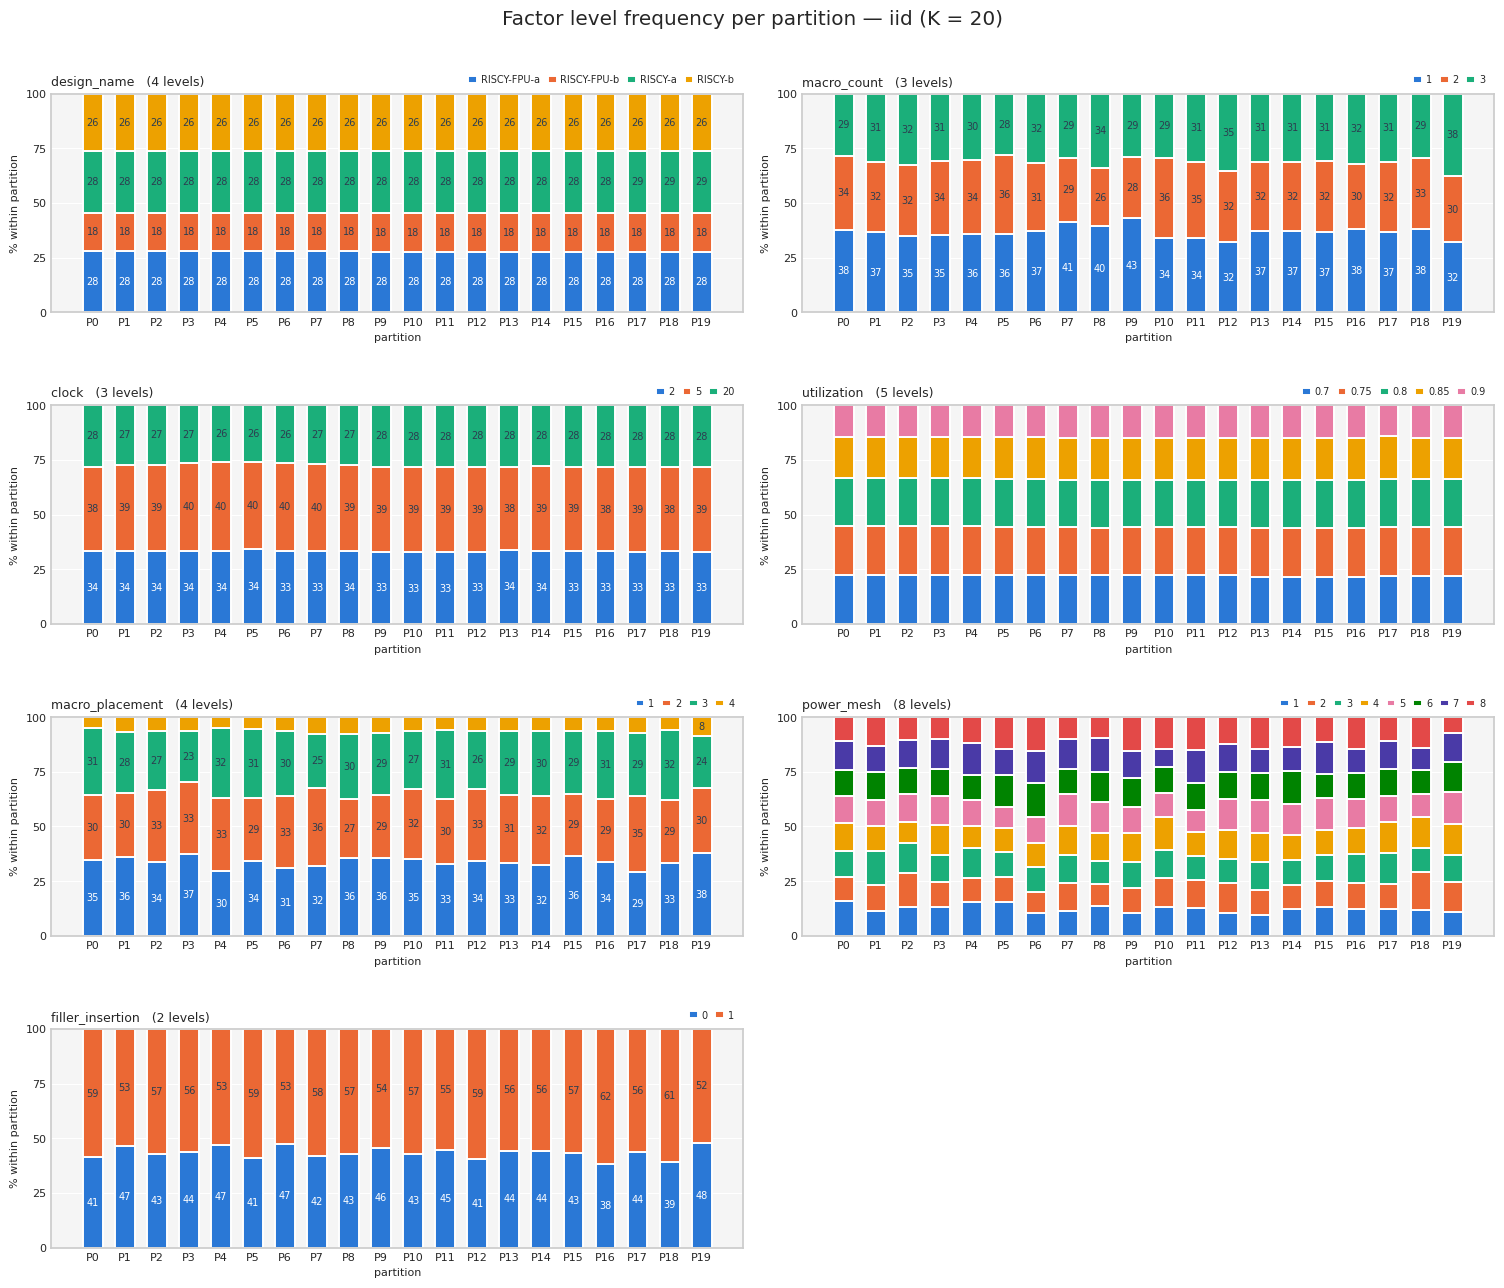

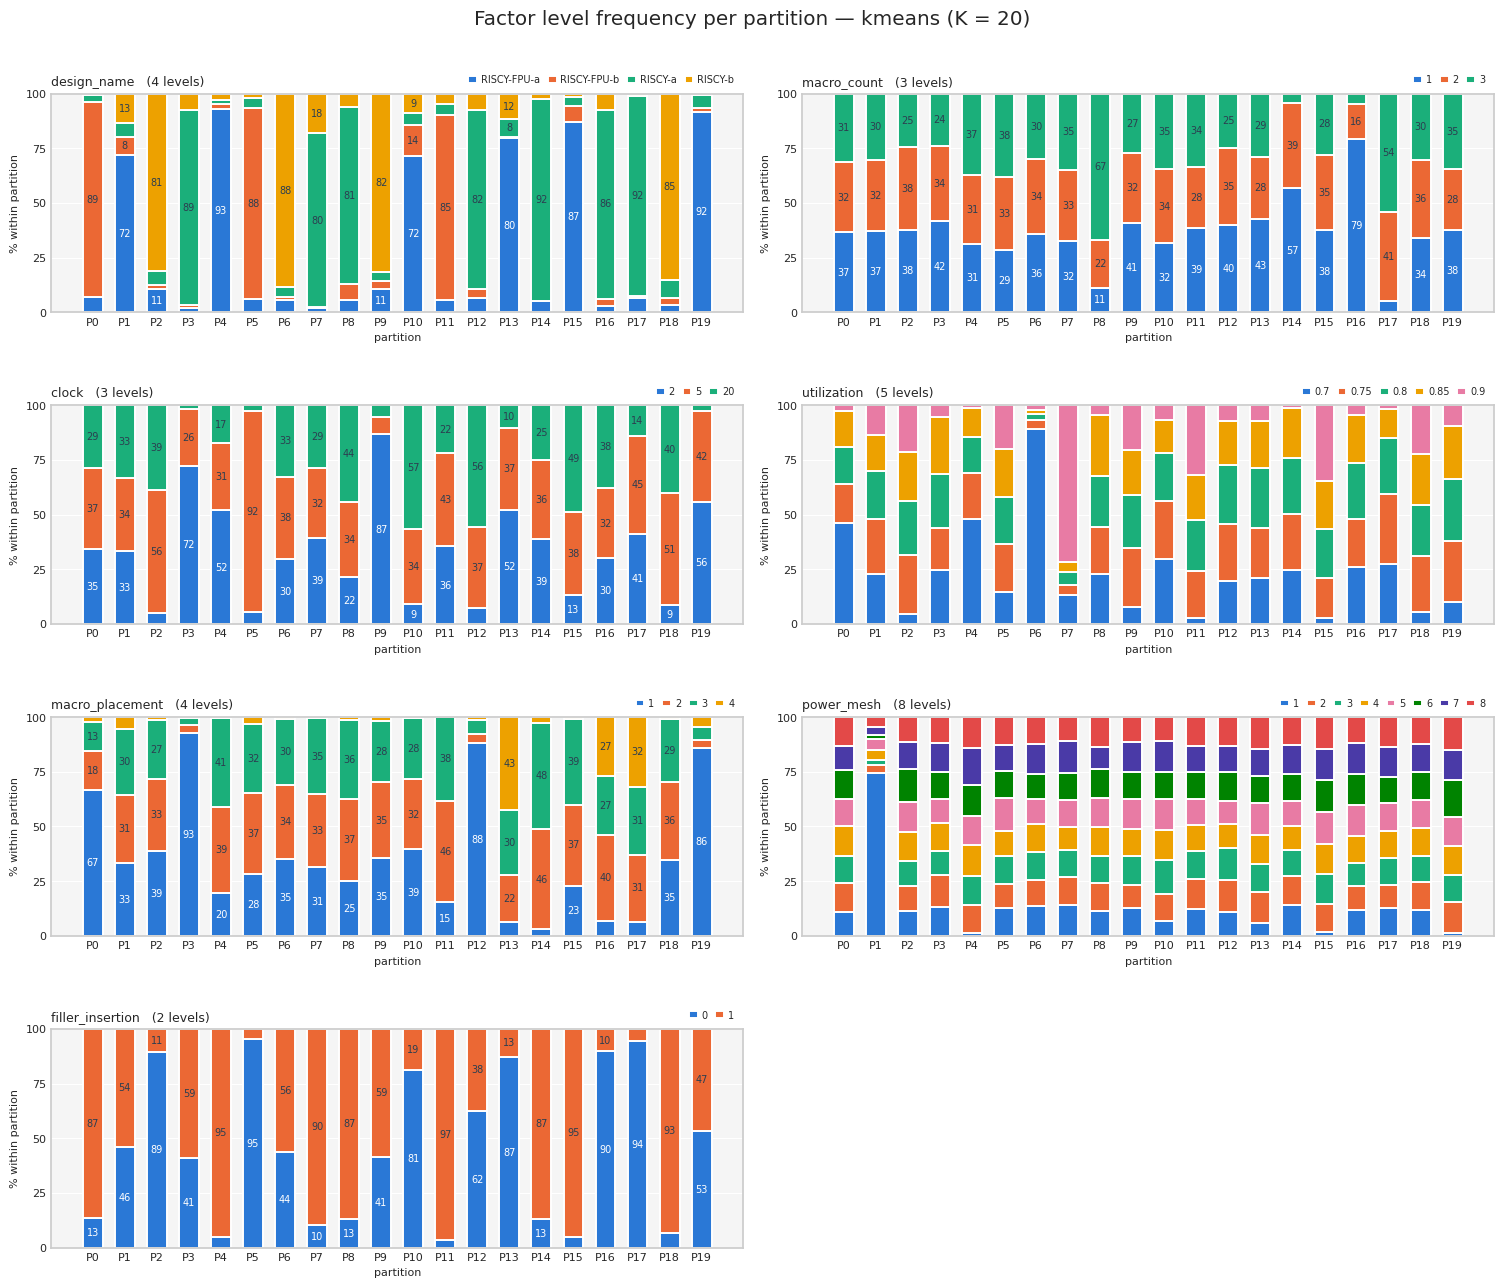

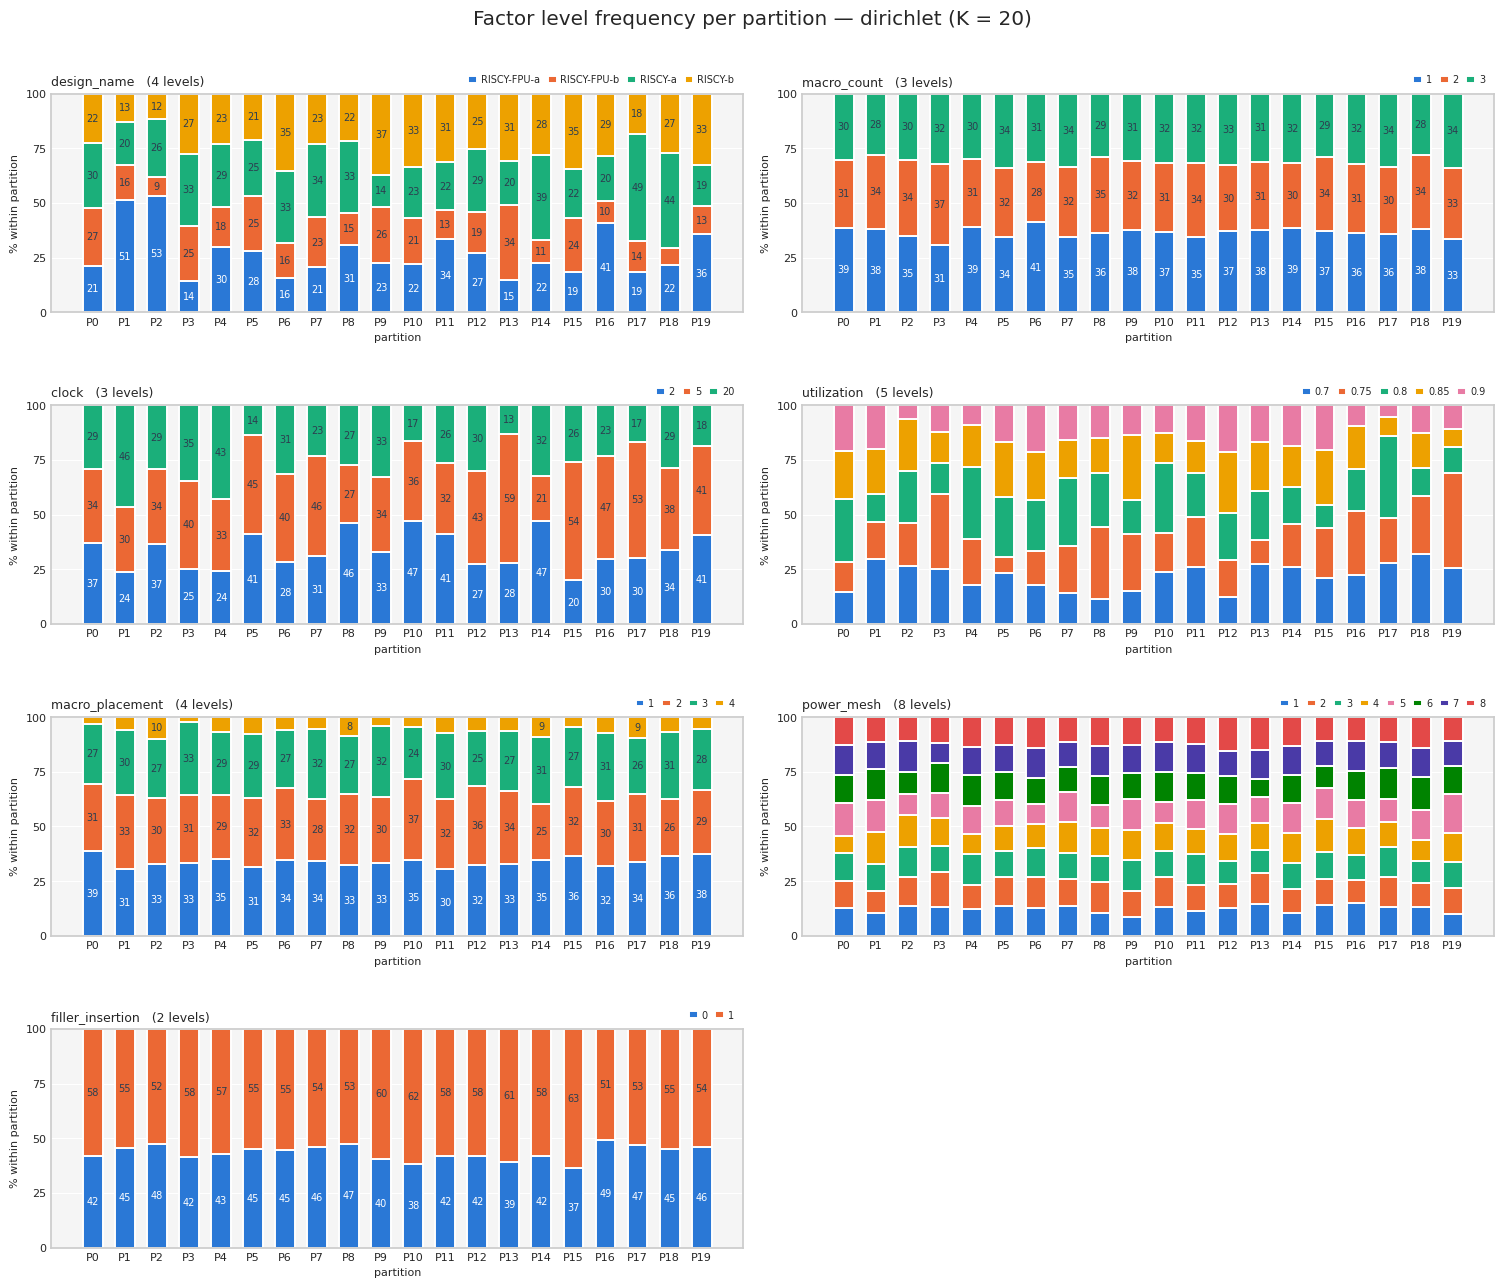

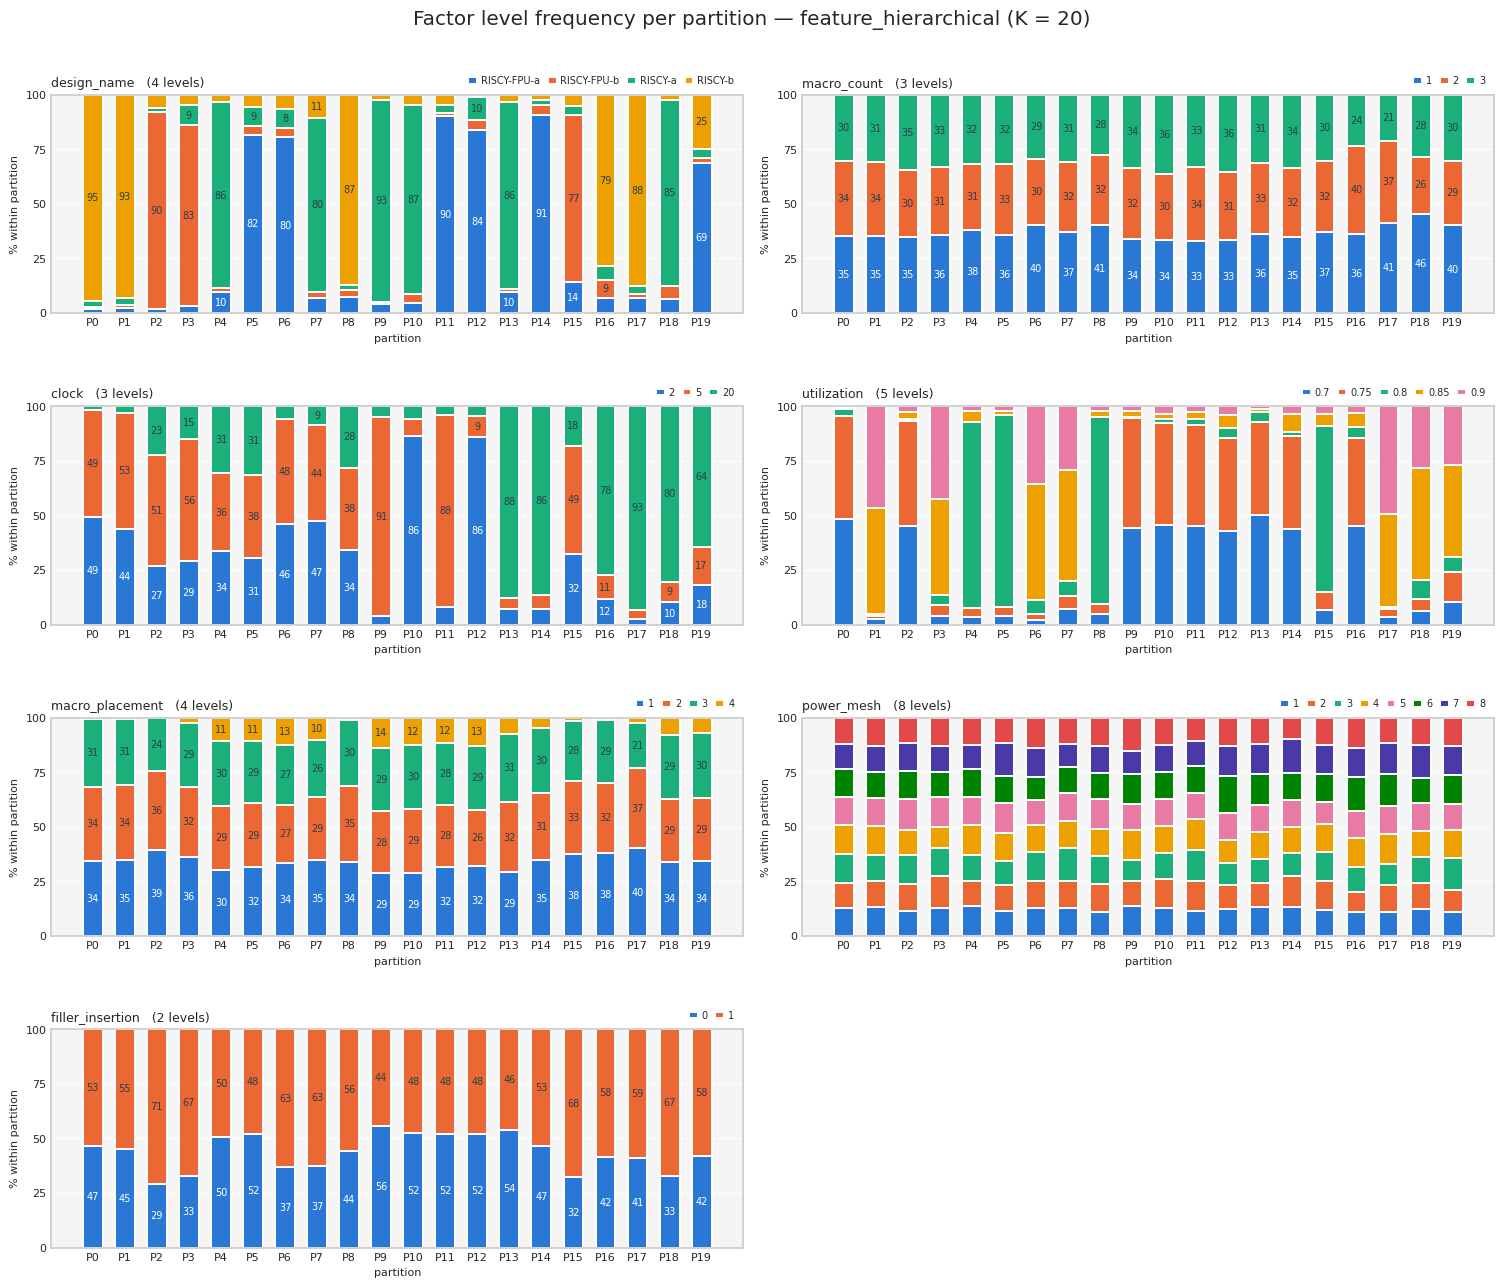

In [9]:
for name in STRAT_NAMES:
    plot_cluster_histograms(
        df, results[name]['assignment'], META_COLS,
        f'Factor level frequency per partition — {name} (K = {N_PARTITIONS})')

## JS Divergence vs Global

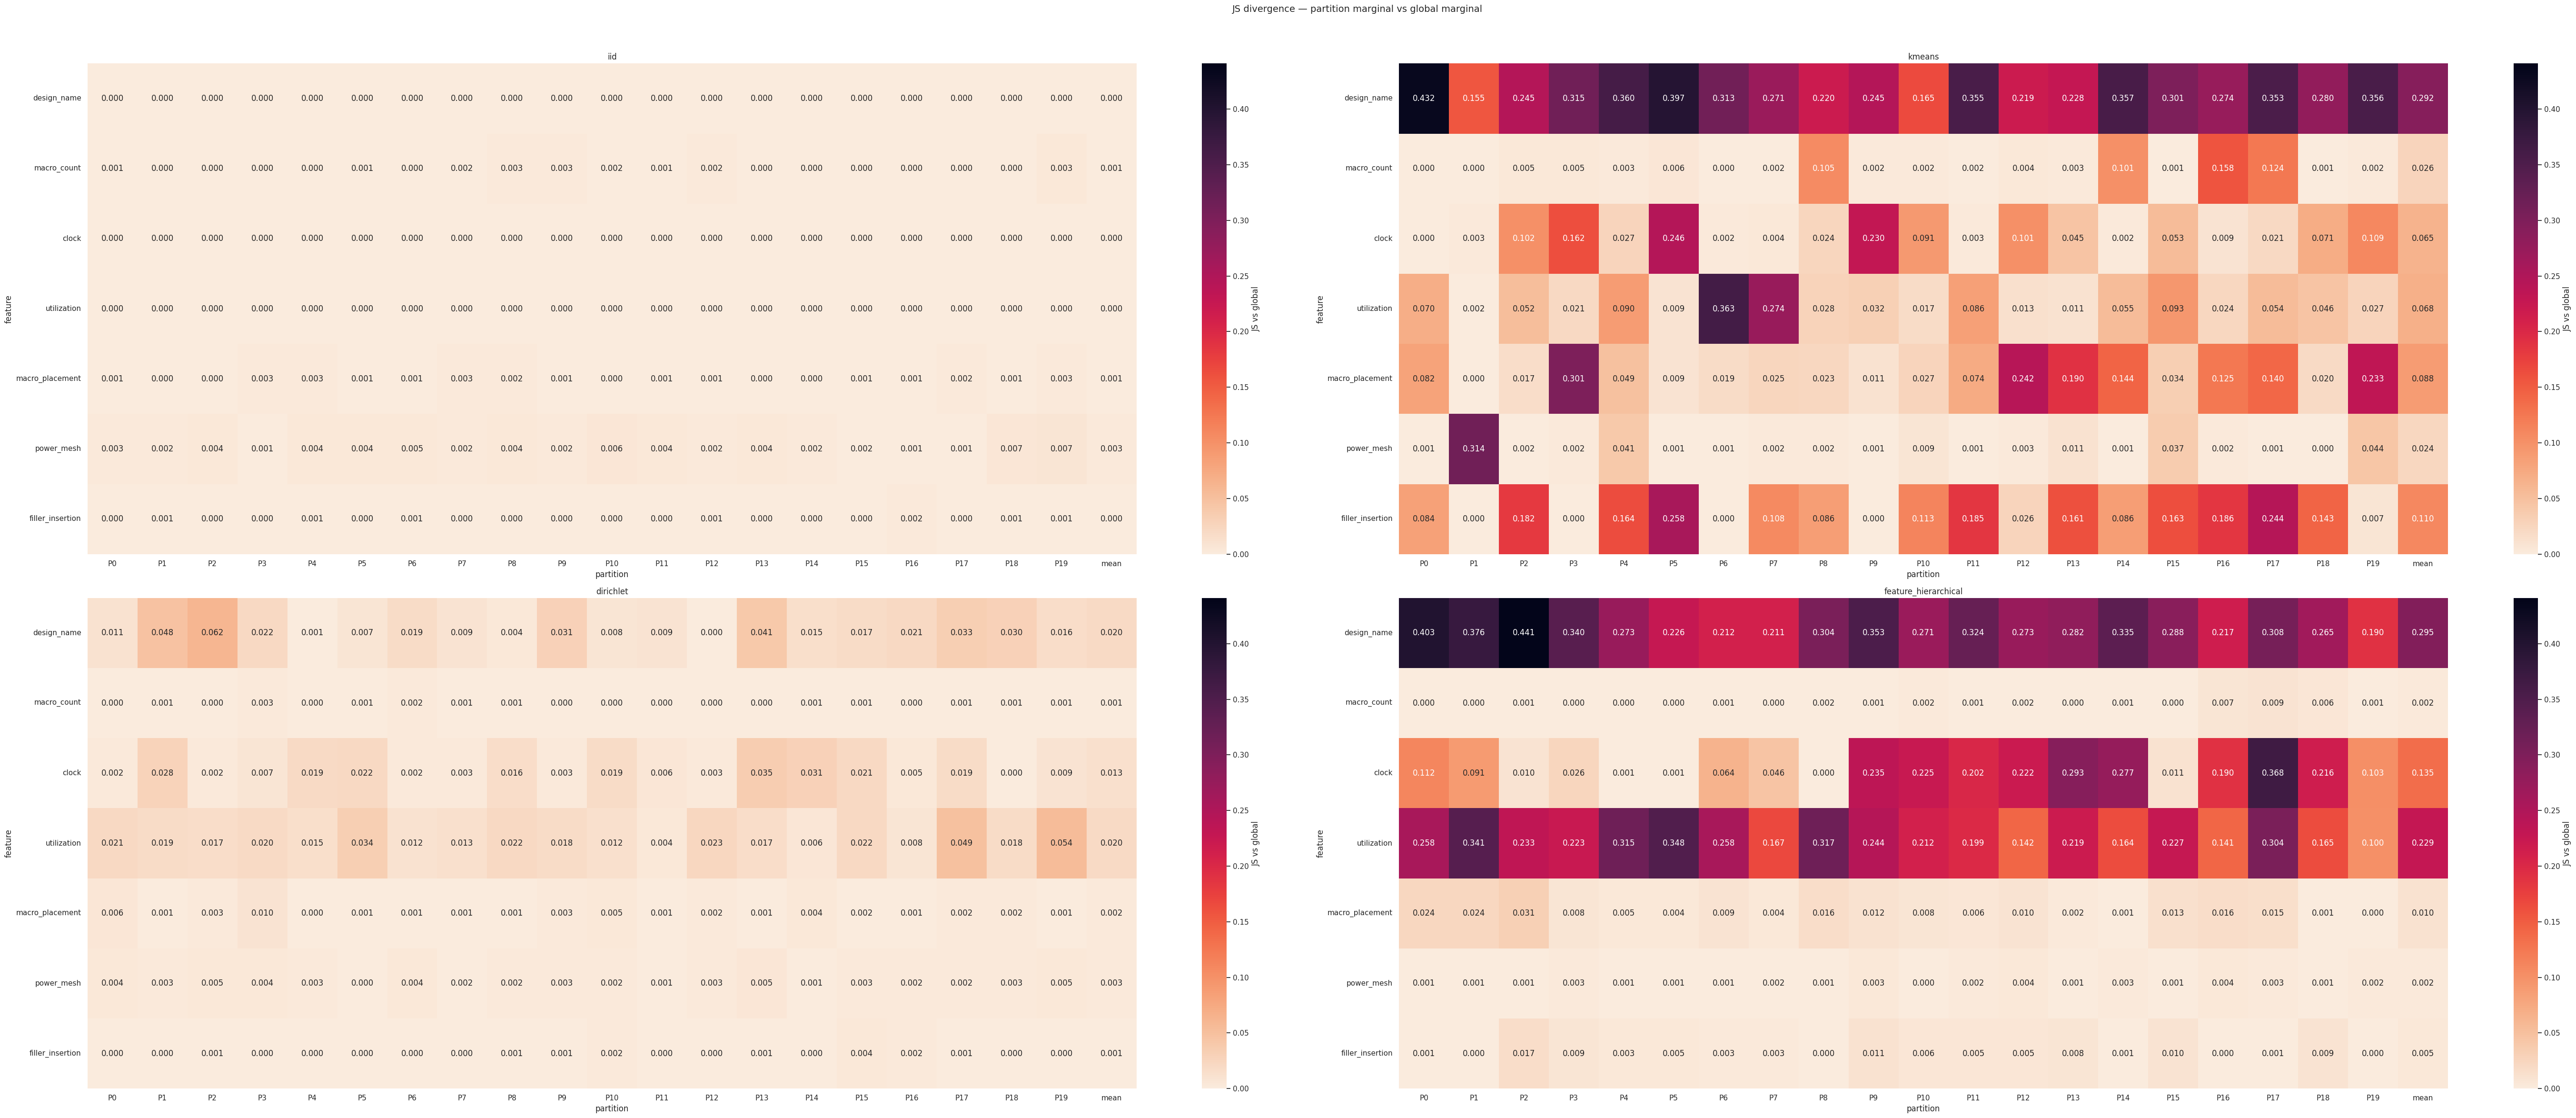

In [10]:
def js_divergence(p, q, eps=1e-12):
    p = np.asarray(p, dtype=float) + eps
    q = np.asarray(q, dtype=float) + eps
    p /= p.sum()
    q /= q.sum()
    m = 0.5 * (p + q)
    kl = lambda a, b: np.sum(a * np.log2(a / b))
    return 0.5 * kl(p, m) + 0.5 * kl(q, m)


def js_table(parts):
    rows = {}
    for col in META_COLS:
        global_vc = df[col].astype(str).value_counts()
        vals = global_vc.index
        g = global_vc.reindex(vals, fill_value=0).to_numpy()
        rows[col] = [
            js_divergence(p[col].astype(str).value_counts().reindex(vals, fill_value=0).to_numpy(), g)
            for p in parts
        ]
    tbl = pd.DataFrame(rows, index=[f'P{i}' for i in range(len(parts))]).T
    tbl['mean'] = tbl.mean(axis=1)
    return tbl


for name in STRAT_NAMES:
    results[name]['js'] = js_table(results[name]['parts'])

fig, axes = plt.subplots(2, int(len(STRAT_NAMES) / 2),
                         figsize=(1.3 * (N_PARTITIONS + 2) * int(len(STRAT_NAMES) / 2), 3 *len(META_COLS) + 2),
                         squeeze=False)
vmax = max(results[n]['js'].to_numpy().max() for n in STRAT_NAMES)
for ax, name in zip(axes.ravel(), STRAT_NAMES):
    sns.heatmap(results[name]['js'], annot=True, fmt='.3f', cmap='rocket_r',
                vmin=0, vmax=vmax, ax=ax,
                cbar_kws={'label': 'JS vs global'})
    ax.set_title(f'{name}')
    ax.set_xlabel('partition')
    ax.set_ylabel('feature')
fig.suptitle('JS divergence — partition marginal vs global marginal', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

In [11]:
mean_js = pd.DataFrame(
    {name: results[name]['js']['mean'] for name in STRAT_NAMES}
)
mean_js.loc['OVERALL'] = mean_js.mean()
mean_js.round(4)

,iid,kmeans,dirichlet,feature_hierarchical
design_name,0.0000,0.2922,0.0202,0.2946
macro_count,0.0010,0.0263,0.0007,0.0017
clock,0.0001,0.0654,0.0126,0.1346
utilization,0.0000,0.0684,0.0202,0.2290
macro_placement,0.0012,0.0882,0.0024,0.0104
power_mesh,0.0033,0.0239,0.0029,0.0018
filler_insertion,0.0005,0.1099,0.0008,0.0048
OVERALL,0.0009,0.0963,0.0085,0.0967


## Coverage Table

In [12]:
coverage_frames = []
for name in STRAT_NAMES:
    rows = []
    for i, p in enumerate(results[name]['parts']):
        row = {'strategy': name, 'partition': f'P{i}', 'n_samples': len(p)}
        for col in META_COLS:
            row[f'unique_{col}'] = p[col].nunique()
        rows.append(row)
    coverage_frames.append(pd.DataFrame(rows))
coverage = pd.concat(coverage_frames, ignore_index=True).set_index(['strategy', 'partition'])
coverage

n_samples  unique_design_name  \
strategy             partition                                  
iid                  P0               354                   4   
                     P1               354                   4   
                     P2               354                   4   
                     P3               354                   4   
                     P4               354                   4   
...                                   ...                 ...   
feature_hierarchical P15              320                   4   
                     P16              267                   4   
                     P17              164                   4   
                     P18              215                   4   
                     P19              231                   4   

                                unique_macro_count  unique_clock  \
strategy             partition                                     
iid                  P0                          3             3   
                     P1                          3             3   
                     P2                          3             3   
                     P3                          3             3   
                     P4                          3             3   
...                                            ...           ...   
feature_hierarchical P15                         3             3   
                     P16                         3             3   
                     P17                         3             3   
                     P18                         3             3   
                     P19                         3             3   

                                unique_utilization  unique_macro_placement  \
strategy             partition                                               
iid                  P0                          5                       4   
                     P1                          5                       4   
                     P2                          5                       4   
                     P3                          5                       4   
                     P4                          5                       4   
...                                            ...                     ...   
feature_hierarchical P15                         5                       4   
                     P16                         5                       4   
                     P17                         5                       4   
                     P18                         5                       4   
                     P19                         5                       4   

                                unique_power_mesh  unique_filler_insertion  
strategy             partition                                              
iid                  P0                         8                        2  
                     P1                         8                        2  
                     P2                         8                        2  
                     P3                         8                        2  
                     P4                         8                        2  
...                                           ...                      ...  
feature_hierarchical P15                        8                        2  
                     P16                        8                        2  
                     P17                        8                        2  
                     P18                        8                        2  
                     P19                        8                        2  

[80 rows x 8 columns]

## Cluster / Partition Overlap

In [13]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

assign_iid = results['iid']['assignment']
rows = []
for name in STRAT_NAMES:
    a = results[name]['assignment']
    row = {'strategy': name, 'ARI_vs_iid': adjusted_rand_score(assign_iid, a),
           'NMI_vs_iid': normalized_mutual_info_score(assign_iid, a)}
    for col in META_COLS:
        y = df[col].astype(str).to_numpy()
        row[f'ARI[{col}]'] = adjusted_rand_score(y, a)
    rows.append(row)
overlap = pd.DataFrame(rows).set_index('strategy').round(3)
overlap

,ARI_vs_iid,NMI_vs_iid,ARI[design_name],ARI[macro_count],ARI[clock],ARI[utilization],ARI[macro_placement],ARI[power_mesh],ARI[filler_insertion]
strategy,,,,,,,,,
iid,1.000,1.000,-0.001,0.000,-0.000,-0.001,-0.000,-0.000,0.000
kmeans,-0.001,0.007,0.176,0.009,0.032,0.030,0.028,0.008,0.052
dirichlet,0.000,0.009,0.010,-0.000,0.006,0.009,-0.000,-0.000,0.000
feature_hierarchical,-0.002,0.002,0.186,-0.000,0.046,0.128,0.001,-0.001,0.003


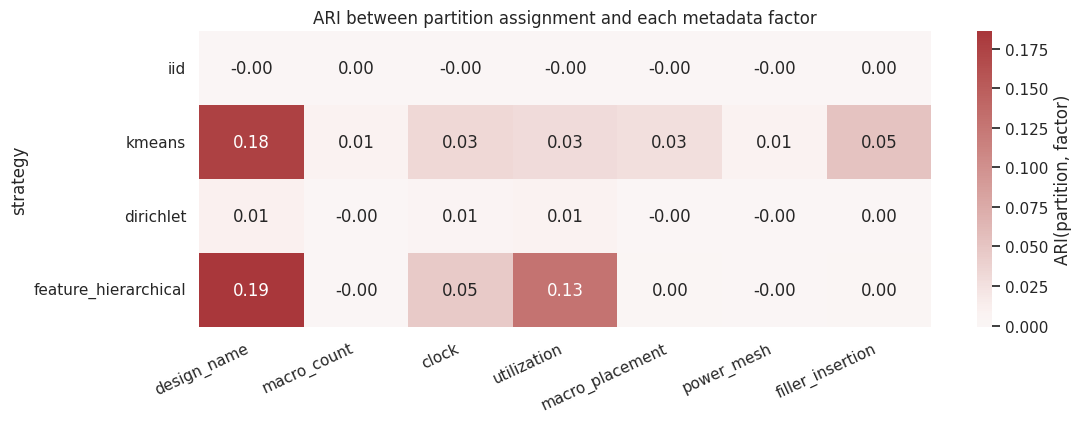

In [14]:
ari_cols = [c for c in overlap.columns if c.startswith('ARI[')]
fig, ax = plt.subplots(figsize=(1.2 * len(ari_cols) + 3, 0.6 * len(STRAT_NAMES) + 2))
sns.heatmap(overlap[ari_cols], annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax,
            cbar_kws={'label': 'ARI(partition, factor)'})
ax.set_title('ARI between partition assignment and each metadata factor')
ax.set_xticklabels([c[4:-1] for c in ari_cols], rotation=25, ha='right')
ax.set_ylabel('strategy')
fig.tight_layout()
plt.show()